In [23]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [24]:
best_pipeline = joblib.load("../models/churn_model.pkl")

In [25]:
df = pd.read_csv("../data/processed/telco_clean.csv")

In [26]:
X = df.drop(["customerID","Churn"], axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [28]:
print("Features used by saved pipeline:")
print(best_pipeline.feature_names_in_)

print("\nCurrent Dataset Features:")
print(X.columns)

Features used by saved pipeline:
['gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure' 'PhoneService'
 'MultipleLines' 'InternetService' 'OnlineSecurity' 'OnlineBackup'
 'DeviceProtection' 'TechSupport' 'StreamingTV' 'StreamingMovies'
 'Contract' 'PaperlessBilling' 'PaymentMethod' 'MonthlyCharges'
 'TotalCharges']

Current Dataset Features:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')


In [29]:
probabilities = best_pipeline.predict_proba(X)[:,1]

In [30]:
precision, recall, thresholds = precision_recall_curve(
    y,
    probabilities
)

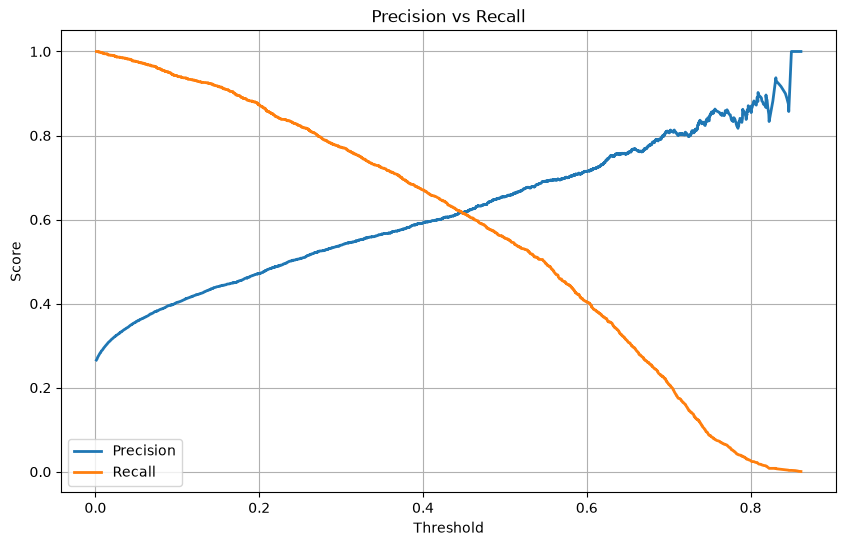

In [36]:
plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision",
    linewidth=2
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall",
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.grid(True)
plt.legend()

plt.show()

In [37]:
f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-10
)

In [38]:
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print(f"Best Threshold : {best_threshold:.3f}")
print(f"Best F1 Score  : {f1_scores[best_index]:.3f}")

Best Threshold : 0.306
Best F1 Score  : 0.637


In [39]:
predictions = (
    probabilities >= best_threshold
).astype(int)

In [40]:
print("Precision :", precision_score(y, predictions))
print("Recall    :", recall_score(y, predictions))
print("F1 Score  :", f1_score(y, predictions))

Precision : 0.543289224952741
Recall    : 0.7688603531300161
F1 Score  : 0.6366858661940629


In [41]:
cm = confusion_matrix(y, predictions)

print(cm)

[[3955 1208]
 [ 432 1437]]


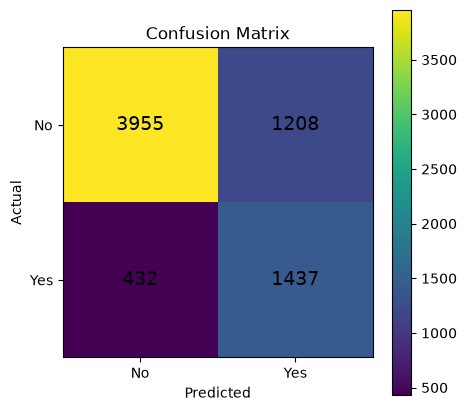

In [42]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], ["No","Yes"])
plt.yticks([0,1], ["No","Yes"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      5163
           1       0.54      0.77      0.64      1869

    accuracy                           0.77      7032
   macro avg       0.72      0.77      0.73      7032
weighted avg       0.81      0.77      0.78      7032

